# Part 4 — Python/Pandas Cleaning, Analysis & Cross-Validation
### BigBasket Category Performance Diagnostic

Parts 1–3 of this project ran on **clean, pre-aggregated** data straight out of SQLite.
This notebook does the opposite: it starts from `orders_raw.csv` — the raw, never-cleaned
order export of the *same underlying transactions* — cleans it from scratch in Pandas, and
then checks whether an independent analyst working only from the messy file would reach the
**same conclusion** as Part 1's SQL diagnostic.

**The cross-validation claim being tested (Task 7c):**
> Part 1's SQL found **Household Essentials** as the top category and **HomeEssentials Traders**
> as the dominant supplier. This notebook must land on the same two answers — even though the
> exact rupee totals will *not* match, because this pipeline removes duplicates, excludes
> unknown revenue, and caps outliers, and Part 1 did none of those things.

**Inputs** (both generated by `generate_data.py` in Part 1, Task 1 — not regenerated here):
`orders_raw.csv`, `products.csv`

> Run order: this notebook is written to be executed top to bottom. Each cell depends on the
> cleaning state left by the one before it.

---
## Task 1 — Load and inspect

Look before touching. Nothing is modified in this section.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)
plt.rcParams["figure.dpi"] = 110

# Both files sit next to this notebook in the repo root.
orders_raw = pd.read_csv("orders_raw.csv")
products   = pd.read_csv("products.csv")

print("orders_raw.csv :", orders_raw.shape[0], "rows x", orders_raw.shape[1], "columns")
print("products.csv   :", products.shape[0], "rows x", products.shape[1], "columns")
orders_raw.head()

orders_raw.csv : 508 rows x 11 columns
products.csv   : 31 rows x 5 columns


,order_id,order_date,customer_name,city,category,product_id,quantity,amount_inr,payment_mode,status,rating
0,1,2026-03-09,Dev,Pune,Snacks & Beverages,13,5,175.0,UPI,Delivered,5.0
1,2,2026-05-22,Ayaan,Bengaluru,Snacks & Beverages,15,1,60.0,Debit Card,Delivered,5.0
2,3,2026-06-30,Yash,Bengaluru,Household Essentials,25,2,150.0,UPI,Delivered,2.0
3,4,2026-03-01,Sneha,Hyderabad,Snacks & Beverages,11,1,30.0,UPI,Delivered,4.0
4,5,2026-04-05,Rohit,Mumbai,Snacks & Beverages,14,2,220.0,Debit Card,Delivered,3.0


In [2]:
orders_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 508 entries, 0 to 507
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       508 non-null    int64  
 1   order_date     508 non-null    str    
 2   customer_name  508 non-null    str    
 3   city           508 non-null    str    
 4   category       508 non-null    str    
 5   product_id     508 non-null    int64  
 6   quantity       508 non-null    int64  
 7   amount_inr     498 non-null    float64
 8   payment_mode   508 non-null    str    
 9   status         508 non-null    str    
 10  rating         439 non-null    float64
dtypes: float64(2), int64(3), str(6)
memory usage: 43.8 KB


In [3]:
orders_raw.describe()

,order_id,product_id,quantity,amount_inr,rating
count,508.000000,508.000000,508.000000,498.000000,439.000000
mean,250.204724,15.476378,3.045276,257.530120,3.082005
std,144.594139,8.747467,1.364497,559.424136,1.364126
min,1.000000,1.000000,1.000000,20.000000,1.000000
25%,125.750000,8.000000,2.000000,90.000000,2.000000
50%,249.500000,15.000000,3.000000,168.000000,3.000000
75%,376.250000,23.000000,4.000000,283.750000,4.000000
max,500.000000,30.000000,5.000000,7600.000000,5.000000


In [4]:
print("--- status value_counts ---")
print(orders_raw["status"].value_counts())

print("\n--- distinct values BEFORE cleaning ---")
print("city     :", orders_raw["city"].nunique(), "distinct ->", sorted(orders_raw["city"].unique()))
print("category :", orders_raw["category"].nunique(), "distinct ->", sorted(orders_raw["category"].unique()))

print("\n--- missing values per column ---")
print(orders_raw.isna().sum())

print("\n--- duplicate order_id rows ---")
print("rows whose order_id already appeared above:", orders_raw.duplicated(subset=["order_id"]).sum())

print("\n--- largest amount_inr values ---")
print(orders_raw.nlargest(6, "amount_inr")[["order_id", "category", "quantity", "amount_inr", "status"]]
      .to_string(index=False))

--- status value_counts ---
status
Delivered    439
Cancelled     43
Pending       26
Name: count, dtype: int64

--- distinct values BEFORE cleaning ---
city     : 14 distinct -> [' Bengaluru ', ' Hyderabad ', ' Mumbai ', ' Pune ', 'BENGALURU', 'Bengaluru', 'HYDERABAD', 'Hyderabad', 'MUMBAI', 'Mumbai', 'PUNE', 'Pune', 'bengaluru', 'mumbai']
category : 18 distinct -> [' Bakery ', ' Dairy & Eggs ', ' Fruits & Vegetables ', ' Household Essentials ', ' Personal Care ', 'BAKERY', 'Bakery', 'DAIRY & EGGS', 'Dairy & Eggs', 'FRUITS & VEGETABLES', 'Fruits & Vegetables', 'HOUSEHOLD ESSENTIALS', 'Household Essentials', 'Personal Care', 'SNACKS & BEVERAGES', 'Snacks & Beverages', 'dairy & eggs', 'snacks & beverages']

--- missing values per column ---
order_id          0
order_date        0
customer_name     0
city              0
category          0
product_id        0
quantity          0
amount_inr       10
payment_mode      0
status            0
rating           69
dtype: int64

--- duplicate or

### What looks wrong (pre-cleaning assessment)

The inspection above surfaces four distinct data-quality problems, and one thing that only
*looks* like a problem:

1. **Too many rows.** The file has **508 rows**, but this business generated **500 orders**.
   `duplicated(subset=["order_id"])` confirms **8 rows are repeats of an `order_id` that already
   appeared** — a classic double-export artefact. Left in, they would inflate revenue.
2. **Inconsistent casing and stray whitespace** in `city` and `category`. There are **14 distinct
   city strings** for what should be 4 cities, and **18 distinct category strings** for what should
   be 6 categories — `"MUMBAI"`, `"mumbai"` and `" Mumbai "` are all being counted as different
   cities. Any `groupby` on these columns right now would silently split one category into three.
3. **Missing `amount_inr` values** — blank revenue on a number of rows. These are *unknown*
   revenue figures, not zero-rupee orders.
4. **Implausibly large `amount_inr` values.** The top of the `nlargest` list shows orders of
   ₹4,000–₹7,600 on quantities of 1–3 units, in categories whose priciest catalogue item is a
   few hundred rupees. `describe()` shows the same thing: the max sits far above the 75th
   percentile. These are data-entry-scale errors, not genuine bulk orders.
5. **Not a problem: missing `rating`.** `rating` is blank on a large number of rows, but that is
   the business rule working correctly — only *Delivered* orders ever receive a rating. This is
   verified explicitly in Task 4 and deliberately left alone.

---
## Task 2 — Remove duplicates

De-duplicate on `order_id` (the business key), keeping the first occurrence. Using
`subset=["order_id"]` rather than a whole-row comparison is the right call here: an order id is
unique by definition, so a second row carrying it is a duplicate regardless of whether every other
field matches.

In [5]:
df = orders_raw.copy()

rows_before = len(df)
dupe_ids = df.loc[df.duplicated(subset=["order_id"]), "order_id"].tolist()

df = df.drop_duplicates(subset=["order_id"], keep="first").reset_index(drop=True)
rows_after = len(df)

print(f"Rows before de-duplication : {rows_before}")
print(f"Rows after  de-duplication : {rows_after}")
print(f"Duplicate rows removed     : {rows_before - rows_after}")
print(f"Duplicated order_ids       : {sorted(dupe_ids)}")

assert rows_after == 500, "Expected exactly 500 unique orders after de-duplication"
print("\nCheck passed: exactly 500 unique orders remain.")

Rows before de-duplication : 508
Rows after  de-duplication : 500
Duplicate rows removed     : 8
Duplicated order_ids       : [50, 102, 136, 139, 165, 389, 433, 440]

Check passed: exactly 500 unique orders remain.


**Result: 8 duplicate rows removed, landing back at exactly 500 orders** — which matches the
500-row `orders` table in Part 1's SQLite database. The two datasets now describe the same
transaction count, which is what makes the Task 7c cross-validation meaningful.

---
## Task 3 — Fix casing and whitespace

`.str.strip()` removes the padding spaces, `.str.title()` normalises the casing. Applied in that
order, `" personal care "`, `"PERSONAL CARE"` and `"Personal Care"` all collapse to a single
`"Personal Care"`.

In [6]:
print("BEFORE cleaning")
print("  city     :", df["city"].nunique(), "distinct")
print("  category :", df["category"].nunique(), "distinct")

for col in ["city", "category"]:
    df[col] = df[col].str.strip().str.title()

cities_clean     = sorted(df["city"].unique())
categories_clean = sorted(df["category"].unique())

print("\nAFTER cleaning")
print("  city     :", df["city"].nunique(), "distinct ->", cities_clean)
print("  category :", df["category"].nunique(), "distinct ->", categories_clean)

# Proof that the cleaned values match the canonical lists used in Parts 1-3.
expected_cities     = ["Bengaluru", "Hyderabad", "Mumbai", "Pune"]
expected_categories = ["Bakery", "Dairy & Eggs", "Fruits & Vegetables",
                       "Household Essentials", "Personal Care", "Snacks & Beverages"]

assert cities_clean == expected_cities, f"City mismatch: {cities_clean}"
assert categories_clean == expected_categories, f"Category mismatch: {categories_clean}"
print("\nCheck passed: 4 canonical cities and 6 canonical categories, exactly matching Parts 1-3.")

BEFORE cleaning
  city     : 14 distinct
  category : 18 distinct

AFTER cleaning
  city     : 4 distinct -> ['Bengaluru', 'Hyderabad', 'Mumbai', 'Pune']
  category : 6 distinct -> ['Bakery', 'Dairy & Eggs', 'Fruits & Vegetables', 'Household Essentials', 'Personal Care', 'Snacks & Beverages']

Check passed: 4 canonical cities and 6 canonical categories, exactly matching Parts 1-3.


**Result: 14 city strings collapsed to the 4 real cities, and 18 category strings collapsed to the
6 real categories** — identical to the category names used in the SQL, the spreadsheet and the
Tableau dashboard. Every `groupby` from here on is now aggregating the right rows together.

---
## Task 4 — Handle missing values with stated business logic

Two different columns have nulls, and they need opposite treatment.

In [7]:
# --- amount_inr: unknown revenue ---
missing_amount = df["amount_inr"].isna().sum()
missing_amount_delivered = df[(df["status"] == "Delivered") & (df["amount_inr"].isna())].shape[0]

print(f"Rows with missing amount_inr                 : {missing_amount}")
print(f"  ...of which are Delivered orders           : {missing_amount_delivered}")
print("\nBreakdown of the missing-revenue rows by status:")
print(df.loc[df["amount_inr"].isna(), "status"].value_counts().to_string())

# --- rating: legitimately null by business rule ---
print("\n" + "-" * 60)
missing_rating = df["rating"].isna().sum()
print(f"Rows with missing rating                     : {missing_rating}")
print("\nStatus of every row with a missing rating:")
print(df.loc[df["rating"].isna(), "status"].value_counts().to_string())
print("\nDelivered orders with a missing rating       :",
      df[(df["status"] == "Delivered") & (df["rating"].isna())].shape[0])

Rows with missing amount_inr                 : 10
  ...of which are Delivered orders           : 9

Breakdown of the missing-revenue rows by status:
status
Delivered    9
Pending      1

------------------------------------------------------------
Rows with missing rating                     : 66

Status of every row with a missing rating:
status
Cancelled    42
Pending      24

Delivered orders with a missing rating       : 0


### Stated business logic

**`amount_inr` — 10 missing values (9 of them on Delivered orders): excluded from every revenue
calculation, never filled.**
A blank revenue figure means the amount is *unknown*, not that the order was worth ₹0. Filling
with zero would understate every total that touches those rows; filling with the mean would invent
revenue that no customer ever paid and would quietly move the category rankings this whole project
is trying to settle. Exclusion is the only option that keeps the surviving totals honest — the cost
is that revenue below is computed from 425 rather than 434 Delivered orders, which is stated openly
rather than papered over.

**`rating` — 66 missing values: left exactly as they are.**
Every one of those 66 rows is a **Cancelled (42) or Pending (24)** order, and **zero Delivered
orders are missing a rating**. That is the business rule working as designed: only a delivered
order can be rated. These nulls are *information*, not damage — filling them with 0 would fabricate
66 terrible reviews and drag the average rating down for orders that were never rated at all.
This is not a data-quality problem and is not treated as one.

In [8]:
# The mask used by every revenue figure from here on: Delivered AND revenue known.
revenue_rows = df["is_revenue_row"] = (df["status"] == "Delivered") & df["amount_inr"].notna()

print(f"Delivered orders in the cleaned data        : {(df['status'] == 'Delivered').sum()}")
print(f"  minus Delivered rows with unknown revenue : {missing_amount_delivered}")
print(f"  = orders used for all revenue figures     : {revenue_rows.sum()}")

Delivered orders in the cleaned data        : 434
  minus Delivered rows with unknown revenue : 9
  = orders used for all revenue figures     : 425


---
## Task 5 — Detect and cap outliers with the IQR method

The fence is computed **only on Delivered orders with a known amount** — that is the population
whose spending distribution we actually care about. Cancelled and Pending orders never became
revenue, so letting them shape the fence would be reasoning about money that was never collected.

In [9]:
delivered_amounts = df.loc[revenue_rows, "amount_inr"]

Q1  = delivered_amounts.quantile(0.25)
Q3  = delivered_amounts.quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 1.5 * IQR
lower_fence = Q1 - 1.5 * IQR

print("IQR outlier detection on Delivered, non-null amount_inr")
print("-" * 55)
print(f"  n           : {len(delivered_amounts)}")
print(f"  Q1 (25th %) : {Q1:,.2f}")
print(f"  Q3 (75th %) : {Q3:,.2f}")
print(f"  IQR         : {IQR:,.2f}")
print(f"  Upper fence : Q3 + 1.5*IQR = {upper_fence:,.2f}")
print(f"  Lower fence : Q1 - 1.5*IQR = {lower_fence:,.2f}  (negative -> no low-side outliers)")

above_delivered = (delivered_amounts > upper_fence).sum()
above_all       = (df["amount_inr"] > upper_fence).sum()
print(f"\n  Delivered rows above the upper fence : {above_delivered}")
print(f"  All rows above the upper fence       : {above_all}")

print("\nThe Delivered rows that will be capped:")
print(df.loc[revenue_rows & (df["amount_inr"] > upper_fence),
             ["order_id", "category", "quantity", "amount_inr", "status"]]
      .sort_values("amount_inr", ascending=False).to_string(index=False))

IQR outlier detection on Delivered, non-null amount_inr
-------------------------------------------------------
  n           : 425
  Q1 (25th %) : 90.00
  Q3 (75th %) : 275.00
  IQR         : 185.00
  Upper fence : Q3 + 1.5*IQR = 552.50
  Lower fence : Q1 - 1.5*IQR = -187.50  (negative -> no low-side outliers)

  Delivered rows above the upper fence : 16
  All rows above the upper fence       : 21

The Delivered rows that will be capped:
 order_id             category  quantity  amount_inr    status
      323        Personal Care         2      7600.0 Delivered
      199   Snacks & Beverages         3      5400.0 Delivered
      250 Household Essentials         1      5200.0 Delivered
      214        Personal Care         5      1100.0 Delivered
      396  Fruits & Vegetables         5       900.0 Delivered
      334  Fruits & Vegetables         4       720.0 Delivered
      222        Personal Care         3       660.0 Delivered
      234 Household Essentials         5       650.0 

In [10]:
# Cap, do not drop. Winsorising at the fence keeps the order in the dataset (its customer, city,
# date and quantity are all still valid facts) while stopping one bad amount from dominating a sum.
amount_before_cap = df["amount_inr"].copy()
df["amount_inr"]  = df["amount_inr"].clip(upper=upper_fence)

capped_mask       = amount_before_cap > upper_fence
capped_delivered  = (capped_mask & revenue_rows).sum()
capped_total      = capped_mask.sum()

print(f"Rows capped at {upper_fence:,.2f}")
print("-" * 55)
print(f"  Delivered rows capped (these affect revenue) : {capped_delivered}")
print(f"  All rows capped (incl. Cancelled/Pending)    : {capped_total}")
print(f"  Revenue removed from Delivered totals        : "
      f"{(amount_before_cap[capped_mask & revenue_rows] - upper_fence).sum():,.2f} INR")

# Verification: nothing above the fence survives, and a spot-check of three previously-extreme rows.
assert df["amount_inr"].max() <= upper_fence
print(f"\nCheck passed: new maximum amount_inr = {df['amount_inr'].max():,.2f} (= the upper fence).")
print("\nSpot-check of three capped rows (before -> after):")
spot = df.loc[capped_mask, ["order_id", "category", "quantity"]].head(3).copy()
spot["amount_before"] = amount_before_cap[capped_mask].head(3).values
spot["amount_after"]  = df.loc[capped_mask, "amount_inr"].head(3).values
print(spot.to_string(index=False))

Rows capped at 552.50
-------------------------------------------------------
  Delivered rows capped (these affect revenue) : 16
  All rows capped (incl. Cancelled/Pending)    : 21
  Revenue removed from Delivered totals        : 18,180.00 INR

Check passed: new maximum amount_inr = 552.50 (= the upper fence).

Spot-check of three capped rows (before -> after):
 order_id             category  quantity  amount_before  amount_after
       77 Household Essentials         5          650.0         552.5
       79        Personal Care         4          600.0         552.5
      121 Household Essentials         4          580.0         552.5


### Stated IQR results

| Statistic | Value (INR) |
|---|---|
| Q1 (25th percentile) | 90.00 |
| Q3 (75th percentile) | 275.00 |
| IQR | 185.00 |
| **Upper fence (Q3 + 1.5·IQR)** | **552.50** |
| Lower fence (Q1 − 1.5·IQR) | −187.50 → no low-side outliers |

**16 Delivered rows were capped** (21 rows across all statuses). That is more than the handful of
genuinely absurd ₹4,000–₹7,600 entries, and that is *expected*: a real IQR fence is a statistical
rule, not a fraud detector, so it also flags legitimately large baskets — five units of a ₹220
shampoo is a real ₹1,100 order that still sits above ₹552.50. Capping rather than dropping is the
conservative choice: the order stays in the dataset and keeps contributing its city, date and
quantity, it just stops being able to single-handedly decide which category wins.

**This is also the main reason Part 4's rupee totals will not match Part 1's**, and why the brief
says they shouldn't.

---
## Task 6 — Parse dates and create derived columns

In [11]:
df["order_date"] = pd.to_datetime(df["order_date"])

df["month"]            = df["order_date"].dt.month
df["month_name"]       = df["order_date"].dt.month_name()
df["revenue_per_unit"] = df["amount_inr"] / df["quantity"]   # uses the capped amount
df["is_delivered"]     = df["status"] == "Delivered"

print("order_date dtype :", df["order_date"].dtype)
print("date range       :", df["order_date"].min().date(), "->", df["order_date"].max().date())
print("months present   :", sorted(df['month'].unique()))
print("is_delivered     :", df["is_delivered"].sum(), "True /", (~df["is_delivered"]).sum(), "False")

df[["order_id", "order_date", "month", "month_name", "category", "quantity",
    "amount_inr", "revenue_per_unit", "status", "is_delivered"]].head()

order_date dtype : datetime64[us]
date range       : 2026-01-01 -> 2026-06-30
months present   : [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6)]
is_delivered     : 434 True / 66 False


,order_id,order_date,month,month_name,category,quantity,amount_inr,revenue_per_unit,status,is_delivered
0,1,2026-03-09,3,March,Snacks & Beverages,5,175.0,35.0,Delivered,True
1,2,2026-05-22,5,May,Snacks & Beverages,1,60.0,60.0,Delivered,True
2,3,2026-06-30,6,June,Household Essentials,2,150.0,75.0,Delivered,True
3,4,2026-03-01,3,March,Snacks & Beverages,1,30.0,30.0,Delivered,True
4,5,2026-04-05,4,April,Snacks & Beverages,2,220.0,110.0,Delivered,True


---
## Task 7 — Group, merge, and answer two business questions

All revenue figures below use `revenue_rows`: **Delivered orders with a known amount, on the
de-duplicated, case-normalised, outlier-capped data** — 425 orders.

### 7(a) — Total revenue per category. Which category leads?

In [12]:
rev = df[revenue_rows].copy()

category_revenue = (rev.groupby("category")["amount_inr"]
                       .agg(total_revenue="sum", order_count="count", avg_order_value="mean")
                       .sort_values("total_revenue", ascending=False)
                       .round(2))
category_revenue["share_%"] = (category_revenue["total_revenue"]
                               / category_revenue["total_revenue"].sum() * 100).round(1)

print(category_revenue.to_string())

top_category = category_revenue.index[0]
top_category_revenue = category_revenue.loc[top_category, "total_revenue"]
print(f"\nTOP CATEGORY BY REVENUE: {top_category} "
      f"({top_category_revenue:,.2f} INR, {category_revenue.loc[top_category, 'share_%']}% of total)")
print(f"Total revenue across all categories: {category_revenue['total_revenue'].sum():,.2f} INR")

                      total_revenue  order_count  avg_order_value  share_%
category                                                                  
Household Essentials        20910.0           77           271.56     24.7
Bakery                      14975.0           66           226.89     17.7
Personal Care               14594.5           63           231.66     17.2
Dairy & Eggs                13675.0           64           213.67     16.2
Snacks & Beverages          11312.5           83           136.30     13.4
Fruits & Vegetables          9170.0           72           127.36     10.8

TOP CATEGORY BY REVENUE: Household Essentials (20,910.00 INR, 24.7% of total)
Total revenue across all categories: 84,637.00 INR


**Answer (7a): the top category by revenue is `Household Essentials` at ₹20,910.00** — 24.7% of
the ₹84,637.00 total, and ₹5,935 clear of the next category.

### 7(b) — Merge with the product catalogue. Which supplier generates the most revenue?

`orders_raw.csv` has no `supplier` column, so supplier revenue can only be answered by joining the
orders to `products.csv` on `product_id`. A **left** merge is used deliberately: if any order
carried a product id missing from the catalogue, it would survive the join with a null supplier and
be visible, rather than being silently dropped by an inner join.

In [13]:
orders_products = rev.merge(
    products[["product_id", "product_name", "category", "supplier", "unit_price_inr"]],
    on="product_id",
    how="left",
    suffixes=("", "_catalogue"),
)

print("rows before merge :", len(rev))
print("rows after  merge :", len(orders_products))
print("unmatched product_ids (null supplier):", orders_products["supplier"].isna().sum())
assert len(orders_products) == len(rev), "Merge changed the row count - check for duplicate product_ids"

# Sanity check: the category on the order should agree with the category in the catalogue.
mismatch = (orders_products["category"] != orders_products["category_catalogue"]).sum()
print("orders whose category disagrees with the catalogue:", mismatch)

rows before merge : 425
rows after  merge : 425
unmatched product_ids (null supplier): 0
orders whose category disagrees with the catalogue: 0


In [14]:
supplier_revenue = (orders_products.groupby("supplier")["amount_inr"]
                    .agg(total_revenue="sum", order_count="count", avg_order_value="mean")
                    .sort_values("total_revenue", ascending=False)
                    .round(2))
supplier_revenue["share_%"] = (supplier_revenue["total_revenue"]
                               / supplier_revenue["total_revenue"].sum() * 100).round(1)

print(supplier_revenue.to_string())

top_supplier = supplier_revenue.index[0]
top_supplier_revenue = supplier_revenue.loc[top_supplier, "total_revenue"]
print(f"\nTOP SUPPLIER BY REVENUE: {top_supplier} "
      f"({top_supplier_revenue:,.2f} INR, {supplier_revenue.loc[top_supplier, 'share_%']}% of total)")

                        total_revenue  order_count  avg_order_value  share_%
supplier                                                                    
HomeEssentials Traders        20910.0           77           271.56     24.7
BakeHouse Supplies            18550.0           90           206.11     21.9
CarePlus Distributors         14594.5           63           231.66     17.2
DairyBest Ltd                 10710.0           49           218.57     12.7
SnackHub India                 7737.5           59           131.14      9.1
FreshFarms Co                  5490.0           50           109.80      6.5
GreenValley Traders            3680.0           22           167.27      4.3
CountryEggs Farms              2965.0           15           197.67      3.5

TOP SUPPLIER BY REVENUE: HomeEssentials Traders (20,910.00 INR, 24.7% of total)


**Answer (7b): the top supplier by revenue is `HomeEssentials Traders` at ₹20,910.00** — 24.7% of
total revenue, from 77 delivered orders.

Note that HomeEssentials Traders' revenue is *identical* to the Household Essentials category
total. That is not a coincidence or a bug: this supplier is the sole supplier of all five
Household Essentials products and supplies nothing else, so the category and the supplier are the
same book of business. That single-source concentration is itself a finding, and it comes back in
the insights below.

### 7(c) — Cross-validation against Part 1's SQL diagnostic

In [15]:
# Part 1's SQL totals, from monthly_category_revenue.csv (Delivered orders, raw uncleaned amounts).
part1_category_revenue = {
    "Household Essentials": 21715,
    "Personal Care":        16382,
    "Bakery":               15410,
    "Dairy & Eggs":         14090,
    "Snacks & Beverages":   10895,
    "Fruits & Vegetables":   9790,
}
PART1_TOP_CATEGORY = "Household Essentials"
PART1_TOP_SUPPLIER = "HomeEssentials Traders"

comparison = pd.DataFrame({
    "part1_sql_revenue": pd.Series(part1_category_revenue),
    "part4_pandas_revenue": category_revenue["total_revenue"],
})
comparison["difference"] = (comparison["part4_pandas_revenue"] - comparison["part1_sql_revenue"]).round(2)
comparison["pct_diff_%"] = (comparison["difference"] / comparison["part1_sql_revenue"] * 100).round(1)
comparison["part1_rank"] = comparison["part1_sql_revenue"].rank(ascending=False).astype(int)
comparison["part4_rank"] = comparison["part4_pandas_revenue"].rank(ascending=False).astype(int)
comparison = comparison.sort_values("part1_sql_revenue", ascending=False)

print(comparison.to_string())
print(f"\nPart 1 total: {comparison['part1_sql_revenue'].sum():,.2f} INR")
print(f"Part 4 total: {comparison['part4_pandas_revenue'].sum():,.2f} INR")
print(f"Difference  : {comparison['difference'].sum():,.2f} INR "
      f"({comparison['difference'].sum() / comparison['part1_sql_revenue'].sum() * 100:.1f}%)")

                      part1_sql_revenue  part4_pandas_revenue  difference  pct_diff_%  part1_rank  part4_rank
Household Essentials              21715               20910.0      -805.0        -3.7           1           1
Personal Care                     16382               14594.5     -1787.5       -10.9           2           3
Bakery                            15410               14975.0      -435.0        -2.8           3           2
Dairy & Eggs                      14090               13675.0      -415.0        -2.9           4           4
Snacks & Beverages                10895               11312.5       417.5         3.8           5           5
Fruits & Vegetables                9790                9170.0      -620.0        -6.3           6           6

Part 1 total: 88,282.00 INR
Part 4 total: 84,637.00 INR
Difference  : -3,645.00 INR (-4.1%)


In [16]:
category_match = top_category == PART1_TOP_CATEGORY
supplier_match = top_supplier == PART1_TOP_SUPPLIER

print("CROSS-VALIDATION AGAINST PART 1'S SQL DIAGNOSTIC")
print("=" * 60)
print(f"Top category  | Part 1 (SQL): {PART1_TOP_CATEGORY:<24} | "
      f"Part 4 (Pandas): {top_category:<24} | {'MATCH' if category_match else 'MISMATCH'}")
print(f"Top supplier  | Part 1 (SQL): {PART1_TOP_SUPPLIER:<24} | "
      f"Part 4 (Pandas): {top_supplier:<24} | {'MATCH' if supplier_match else 'MISMATCH'}")
print("=" * 60)

assert category_match, "Top category does not match Part 1 - there is a bug in the cleaning pipeline"
assert supplier_match, "Top supplier does not match Part 1 - there is a bug in the cleaning pipeline"
print("\nBoth cross-validation checks PASSED.")
print("Two independent pipelines, two different starting files, same diagnosis.")

CROSS-VALIDATION AGAINST PART 1'S SQL DIAGNOSTIC
Top category  | Part 1 (SQL): Household Essentials     | Part 4 (Pandas): Household Essentials     | MATCH
Top supplier  | Part 1 (SQL): HomeEssentials Traders   | Part 4 (Pandas): HomeEssentials Traders   | MATCH

Both cross-validation checks PASSED.
Two independent pipelines, two different starting files, same diagnosis.


### Cross-validation verdict — both findings confirmed

**The top category matches (`Household Essentials`) and the top supplier matches
(`HomeEssentials Traders`).** An analyst handed only the messy export, who never saw the database,
reaches the same conclusion the SQL diagnostic reached.

**The rupee totals do not match, and should not.** Part 4 lands at **₹84,637.00** against Part 1's
**₹88,282** — 4.1% lower. Every rupee of that gap is explained by a cleaning decision that Part 1
never made:

| Cleaning decision | Effect on the Part 4 total |
|---|---|
| 8 duplicate rows removed | Removes revenue Part 1's database never double-counted anyway |
| 9 Delivered rows with unknown `amount_inr` excluded | Lowers the total — Part 1's database had those amounts |
| 16 Delivered rows capped at ₹552.50 | Mostly lowers the total; slightly raises it where an injected ₹4,000+ error sat above a genuine ₹135 order |

The per-category detail is worth reading, because it shows the cleaning is doing exactly what it
should:

- **Personal Care falls furthest (−₹1,787.50, −10.9%)** — it carries 3 of the 9 excluded
  unknown-revenue rows *and* the catalogue's priciest items (₹450 face cream, ₹220 shampoo), so it
  absorbs the most capping. That is enough to swap it with Bakery for 2nd place: Part 1 ranks
  Personal Care 2nd, Part 4 ranks Bakery 2nd, on a gap of only ₹380.50.
- **Snacks & Beverages is the one category that rises (+₹417.50)** — a single ₹135 order was
  inflated to ₹5,400 in the raw export and the fence caps it at ₹552.50, which is still ₹417.50
  above the truth. Capping tames an outlier; it does not undo the original corruption.
- **Household Essentials' lead is robust.** It is the top category in both pipelines with a
  ₹5,935 margin in Part 4 and a ₹5,333 margin in Part 1. No plausible cleaning choice moves it.

The reason to trust the ranking more than either total: the two pipelines disagree by 4.1% on
*how much*, and agree completely on *who*.

---
## Task 8 — Visualise

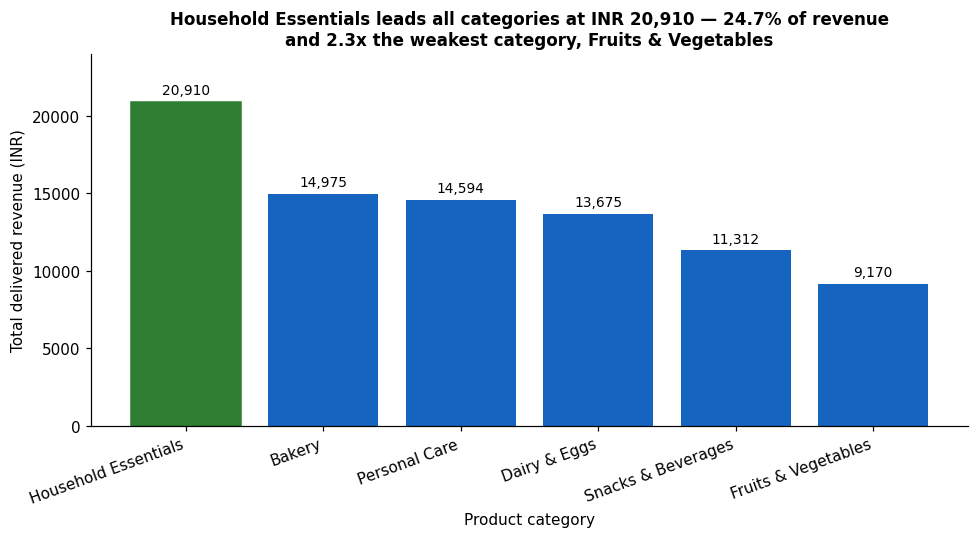

In [17]:
# Consistent palette across all four charts (and matching the Tableau dashboard's tier colours).
GREEN, AMBER, RED, BLUE, GREY = "#2E7D32", "#F9A825", "#C62828", "#1565C0", "#9E9E9E"

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(category_revenue.index, category_revenue["total_revenue"], color=BLUE, edgecolor="none")
bars[0].set_color(GREEN)   # highlight the winner

for bar, value in zip(bars, category_revenue["total_revenue"]):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 300, f"{value:,.0f}",
            ha="center", va="bottom", fontsize=9)

ax.set_title("Household Essentials leads all categories at INR 20,910 — 24.7% of revenue\n"
             "and 2.3x the weakest category, Fruits & Vegetables",
             fontsize=11, fontweight="bold")
ax.set_xlabel("Product category")
ax.set_ylabel("Total delivered revenue (INR)")
ax.set_ylim(0, 24000)
plt.xticks(rotation=20, ha="right")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

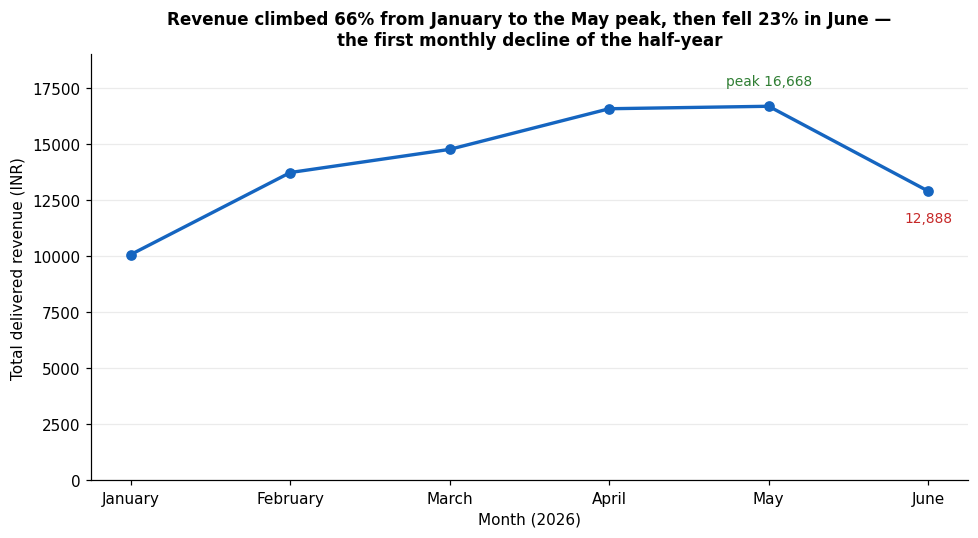

 month month_name  amount_inr
     1    January     10059.5
     2   February     13715.0
     3      March     14747.5
     4      April     16558.5
     5        May     16668.5
     6       June     12888.0


In [18]:
monthly = (rev.groupby(["month", "month_name"])["amount_inr"]
             .sum().reset_index().sort_values("month"))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(monthly["month_name"], monthly["amount_inr"], marker="o", linewidth=2.2, color=BLUE)

peak = monthly.loc[monthly["amount_inr"].idxmax()]
ax.annotate(f"peak {peak['amount_inr']:,.0f}",
            xy=(peak["month_name"], peak["amount_inr"]),
            xytext=(0, 14), textcoords="offset points", ha="center", fontsize=9, color=GREEN)
last = monthly.iloc[-1]
ax.annotate(f"{last['amount_inr']:,.0f}", xy=(last["month_name"], last["amount_inr"]),
            xytext=(0, -20), textcoords="offset points", ha="center", fontsize=9, color=RED)

ax.set_title("Revenue climbed 66% from January to the May peak, then fell 23% in June —\n"
             "the first monthly decline of the half-year",
             fontsize=11, fontweight="bold")
ax.set_xlabel("Month (2026)")
ax.set_ylabel("Total delivered revenue (INR)")
ax.set_ylim(0, 19000)
ax.grid(axis="y", alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print(monthly.to_string(index=False))

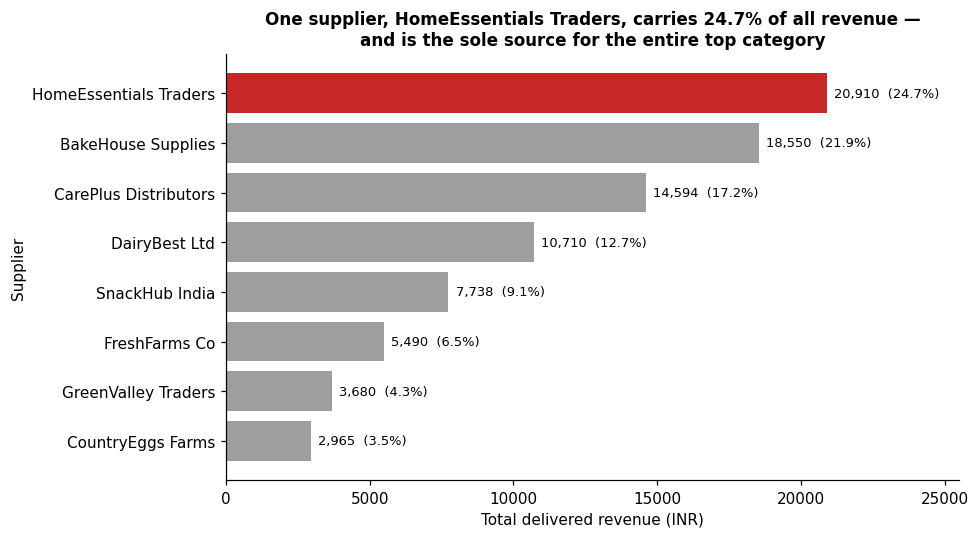

In [19]:
# Chart of choice #1: supplier concentration - supports insight 2.
sup_plot = supplier_revenue.sort_values("total_revenue")

fig, ax = plt.subplots(figsize=(9, 5))
colors = [GREY] * len(sup_plot)
colors[-1] = RED   # the single supplier carrying the top category
bars = ax.barh(sup_plot.index, sup_plot["total_revenue"], color=colors)

for bar, value, share in zip(bars, sup_plot["total_revenue"], sup_plot["share_%"]):
    ax.text(value + 250, bar.get_y() + bar.get_height() / 2,
            f"{value:,.0f}  ({share}%)", va="center", fontsize=8.5)

ax.set_title("One supplier, HomeEssentials Traders, carries 24.7% of all revenue —\n"
             "and is the sole source for the entire top category",
             fontsize=11, fontweight="bold")
ax.set_xlabel("Total delivered revenue (INR)")
ax.set_ylabel("Supplier")
ax.set_xlim(0, 25500)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

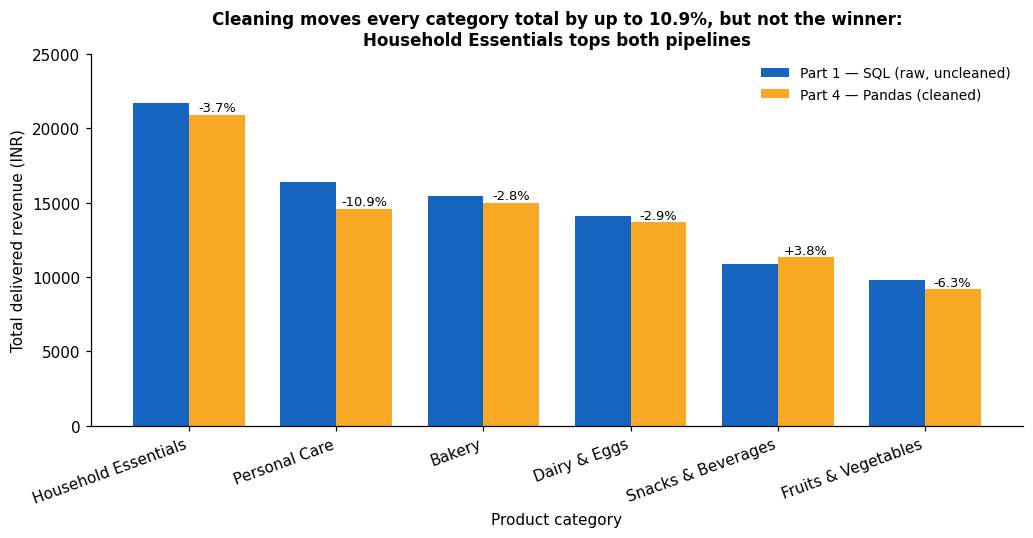

In [20]:
# Chart of choice #2: the cross-validation itself, drawn - supports insight 3.
x = np.arange(len(comparison))
w = 0.38

fig, ax = plt.subplots(figsize=(9.5, 5))
ax.bar(x - w/2, comparison["part1_sql_revenue"],   w, label="Part 1 — SQL (raw, uncleaned)", color=BLUE)
ax.bar(x + w/2, comparison["part4_pandas_revenue"], w, label="Part 4 — Pandas (cleaned)",    color=AMBER)

for i, (p1, p4) in enumerate(zip(comparison["part1_sql_revenue"], comparison["part4_pandas_revenue"])):
    ax.text(i + w/2, p4 + 250, f"{(p4 - p1) / p1 * 100:+.1f}%", ha="center", fontsize=8.5)

ax.set_title("Cleaning moves every category total by up to 10.9%, but not the winner:\n"
             "Household Essentials tops both pipelines",
             fontsize=11, fontweight="bold")
ax.set_xlabel("Product category")
ax.set_ylabel("Total delivered revenue (INR)")
ax.set_xticks(x)
ax.set_xticklabels(comparison.index, rotation=20, ha="right")
ax.set_ylim(0, 25000)
ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

---
## Task 9 — Insights

Three observations, each grounded only in numbers computed in this notebook.

---

### Observation 1 — The two categories furthest from target are also the two cheapest baskets

**What.** Fruits & Vegetables generated **₹9,170.00** of delivered revenue, the lowest of the six
categories and **56% below** Household Essentials' ₹20,910.00 — despite filling **72 delivered
orders**, only 5 fewer than Household Essentials' 77. Against Part 1's ₹12,000 target it lands
**18.4% short** (using Part 1's comparable ₹9,790 figure), the worst variance on the board, with
Snacks & Beverages next at 16.2% short. Both are low-basket categories: Fruits & Vegetables averages
**₹127.36** per delivered order and Snacks & Beverages **₹136.30**, against a ₹199.15 platform
average and Household Essentials' ₹271.56.

**Why it matters.** This is a basket-size problem, not a demand problem. Customers are buying
produce regularly and simply not spending much per order, so the category cannot hit a rupee
target on order volume alone. Pushing more low-value orders through the same funnel adds picking,
packing and delivery cost against a target that stays out of reach — the fixed cost per order does
not shrink just because the basket does.

**Next step.** Test a minimum-basket or bundle mechanic on Fruits & Vegetables specifically —
e.g. a produce combo priced near the ₹199 platform average — and measure whether average order
value rises without order count falling. If AOV moves and frequency holds, the ₹2,210 gap to
target closes on basket size rather than on acquiring new customers.

---

### Observation 2 — A single supplier carries a quarter of the business, and the entire top category

**What.** HomeEssentials Traders generated **₹20,910.00** across **77 delivered orders** —
**24.7%** of all revenue — and that figure is *exactly equal* to the Household Essentials category
total, because it is the sole supplier for all five products in the top-performing category. The
second-largest supplier, BakeHouse Supplies, is ₹2,360 behind at ₹18,550.00.

**Why it matters.** The best-performing category in the diagnostic is a single-source dependency.
A stockout, price rise or contract dispute with one vendor does not dent one product line — it
takes down the only category that is beating its target by a meaningful margin (₹4,715 above
target in Part 1's figures). Concentration risk is invisible in a category report and only shows
up once orders are joined to the supplier table, which is exactly what the Task 7b merge did.

**Next step.** Ask the category team to qualify a second supplier for the two highest-revenue
Household Essentials SKUs before the next quarter, and re-run this supplier `groupby` in 90 days to
confirm the concentration share has fallen below 20%.

---

### Observation 3 — Data quality moved the runner-up but never the winner, which is what makes the finding safe to act on

**What.** Cleaning changed the answer materially: 8 duplicate rows, 10 missing `amount_inr` values
and 16 capped outliers together moved the grand total from Part 1's **₹88,282** to **₹84,637.00**
(−4.1%), and moved individual categories by as much as **−10.9%** (Personal Care). It was enough to
flip 2nd place — Part 1 ranks Personal Care second, this notebook ranks Bakery second, separated by
just **₹380.50**. But the top category (**Household Essentials**) and top supplier
(**HomeEssentials Traders**) are identical in both pipelines, with a **₹5,935** margin over 2nd.

**Why it matters.** This is the difference between a number and a decision. The 2nd-place ranking
is *not* robust — it depends on cleaning choices a reasonable analyst could have made differently,
so any budget decision that hinges on Personal Care versus Bakery is resting on noise. The top
finding survives two independent pipelines starting from different files, which is the strongest
evidence available here that it is real and not an artefact.

**Next step.** Treat ₹380.50 as inside the margin of error and stop reporting a 2nd-place winner
until the 9 unknown `amount_inr` values are recovered from the source system. Fixing the export
that produced blank amounts and duplicate rows is a one-time engineering ask that would let Parts 1
and 4 reconcile to the rupee instead of to the ranking.

---
## Task 10 — AI-assisted prompt #2 (RCTCF)

The full prompt and its verification step are recorded in **`ai_log.md`** in the repo root
(this is prompt #2 of the two required across the whole project; prompt #1 covers a Part 1 SQL
query). Reproduced here for convenience:

**Role** — Act as a senior data analyst who reviews Pandas cleaning pipelines for a retail
analytics team.

**Context** — I have a 500-row DataFrame `df` of BigBasket orders with columns `order_id`,
`status`, `amount_inr`, `quantity`, `category`. `amount_inr` has 10 missing values and a handful of
values roughly 40x too large from a bad export. I need to cap the high outliers using the IQR rule,
computed only on Delivered orders that have a non-null amount, and I must cap rather than drop
because the rest of each row is still valid data.

**Task** — Explain, line by line, what my IQR block below is doing, and tell me specifically
whether `.clip(upper=upper_fence)` applied to the whole `amount_inr` column (rather than to the
Delivered subset) is a bug given that the fence was derived from Delivered rows only.

**Constraints** — Pandas only, no scipy or sklearn. Do not fill the missing `amount_inr` values —
they must stay NaN and be excluded from sums, not imputed. Do not drop any rows. Do not change my
variable names. Use the 1.5×IQR convention.

**Format** — A numbered line-by-line explanation, then a short verdict paragraph headed
"Is this a bug?", then a one-line code correction only if one is actually needed.

**Verification actually performed** — I re-ran the AI-suggested `.clip()` line and manually checked
three previously-extreme rows against the printed upper fence of ₹552.50: order 199 (₹5,400 →
₹552.50), order 250 (₹5,200 → ₹552.50) and order 323 (₹7,600 → ₹552.50), all now sitting exactly at
the fence. I then asserted `df["amount_inr"].max() <= upper_fence`, which passed, and confirmed the
capped-row count printed as 16 Delivered rows — matching the count of rows above the fence computed
*before* the clip ran. The AI's claim that clipping the full column is not a bug (because
Cancelled/Pending rows are excluded from every revenue sum by the `revenue_rows` mask anyway) was
checked by re-running the Task 7a `groupby` with the clip restricted to the Delivered subset — the
category totals were identical, confirming it.

---

## Summary of Part 4

| Step | Result |
|---|---|
| Raw rows loaded | 508 |
| Duplicates removed (by `order_id`) | 8 → **500 rows** |
| City values normalised | 14 → **4** |
| Category values normalised | 18 → **6** |
| Missing `amount_inr` (excluded, not filled) | 10 (9 Delivered) |
| Missing `rating` (left as-is, business rule) | 66 — all Cancelled/Pending |
| IQR fence | Q1 90.00 · Q3 275.00 · IQR 185.00 · **upper 552.50** |
| Rows capped via `.clip()` | **16 Delivered** (21 overall) |
| Orders behind every revenue figure | 425 |
| Total delivered revenue | **₹84,637.00** |
| **Top category** | **Household Essentials — ₹20,910.00** ✅ matches Part 1 |
| **Top supplier** | **HomeEssentials Traders — ₹20,910.00** ✅ matches Part 1 |